# 02 — Modeling and Interpretation

Train a churn classifier on the BankChurners dataset and interpret what it learned. The cleaning decisions from `01_eda.ipynb` are reapplied here so the notebook stands alone.

**Contents:**
1. Load and clean data.
2. Preprocessing pipeline (scaling + one-hot encoding).
3. Train / validation / test split.
4. Baseline logistic regression.
5. Tuned XGBoost classifier.
6. Model comparison.
7. SHAP interpretation.

Saves a trained model to `models/` for the cost-analysis notebook and the Streamlit dashboard.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from xgboost import XGBClassifier
import shap

In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 3)

RANDOM_SEED = 42

## Load and clean data

Reapplies the cleaning decisions from the EDA notebook:

- Drop `CLIENTNUM` (identifier) and the two `Naive_Bayes_Classifier_*` artifact columns.
- Create the binary `churned` target (1 = Attrited, 0 = Existing).
- Drop the original `Attrition_Flag` column since it is fully captured by `churned`.
- `"Unknown"` in the categorical columns is left as its own category — the preprocessing pipeline below will give it its own dummy.

In [3]:
df = pd.read_csv("../data/raw/BankChurners.csv")

df = df.drop(columns=[
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
])

df["churned"] = (df["Attrition_Flag"] == "Attrited Customer").astype(int)
df = df.drop(columns=["Attrition_Flag"])

df.shape

(10127, 20)

In [4]:
df.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churned
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


## Preprocessing pipeline

A `ColumnTransformer` applies different transforms to each feature type:

- **Numeric** → `StandardScaler` — centres at 0, unit variance. Required for logistic regression to converge well; harmless for trees.
- **Categorical** → `OneHotEncoder(handle_unknown="ignore")` — one binary column per category. The `handle_unknown="ignore"` setting means any unseen category at predict time gets all-zero dummies instead of raising — a useful safety net for production.

The preprocessor is *defined* here but *fitted later* — only on training data, inside a `Pipeline`. This avoids leaking test-set statistics into the scaler.

In [5]:
target = "churned"
features = df.drop(columns=[target])

numeric_cols = features.select_dtypes(include="number").columns.tolist()
categorical_cols = features.select_dtypes(include="object").columns.tolist()

print(f"Numeric ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

Numeric (14): ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
Categorical (5): ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


/var/folders/s1/ydqc1kqd1_l_3stqdlcsdygm0000gn/T/ipykernel_60428/2005881057.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = features.select_dtypes(include="object").columns.tolist()


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Train / validation / test split

70 / 15 / 15, stratified on `churned`. `train_test_split` doesn't do three-way splits in one call, so two passes: 70% train vs 30% holdout, then the holdout split 50/50 into validation and test.

The validation set is for model selection and threshold experiments during modeling. The test set is held back untouched until the cost analysis in notebook 03 — peeking at it would invalidate every business number that comes out of it.

In [7]:
X = df.drop(columns=["churned"])
y = df["churned"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED
)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (7088, 19)
Val:   (1519, 19)
Test:  (1520, 19)


### Verify class balance is preserved

All three splits should match the 16.07% churn rate from the full data. If any differs noticeably, stratification is broken and needs fixing before any modeling.

In [8]:
print(f"Full:  {y.mean():.4f}")
print(f"Train: {y_train.mean():.4f}")
print(f"Val:   {y_val.mean():.4f}")
print(f"Test:  {y_test.mean():.4f}")

Full:  0.1607
Train: 0.1607
Val:   0.1606
Test:  0.1605


All four within 0.02 percentage points. Stratification did its job — the model will see the same class distribution at every stage.

## Baseline: logistic regression

A linear classifier is the canonical baseline. If a fancier model doesn't beat this, the complexity isn't earning its keep.

The full pipeline is `preprocessor → LogisticRegression(class_weight="balanced")`. The class weighting upweights churners so the model doesn't just learn "predict 'not churn' for everyone".

Evaluated on the validation set using ROC-AUC, PR-AUC, and a confusion matrix at the default 0.5 threshold.

In [9]:
baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED)),
])

baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [10]:
y_val_pred = baseline.predict(X_val)
y_val_proba = baseline.predict_proba(X_val)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba):.3f}")
print(f"PR-AUC:  {average_precision_score(y_val, y_val_proba):.3f}")

ROC-AUC: 0.916
PR-AUC:  0.709


In [11]:
print(classification_report(y_val, y_val_pred, target_names=["Existing", "Attrited"]))

              precision    recall  f1-score   support

    Existing       0.96      0.86      0.91      1275
    Attrited       0.53      0.84      0.65       244

    accuracy                           0.85      1519
   macro avg       0.75      0.85      0.78      1519
weighted avg       0.89      0.85      0.87      1519



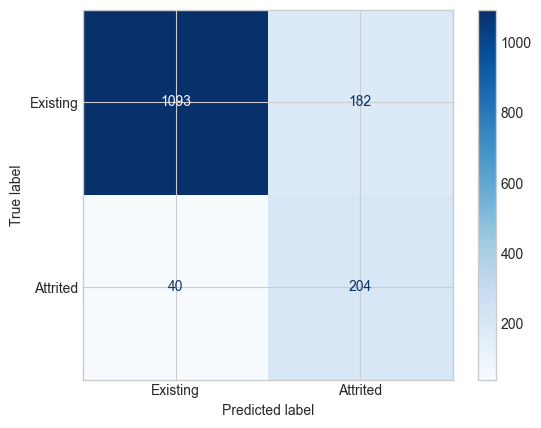

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    display_labels=["Existing", "Attrited"],
    cmap="Blues",
);

### Interpreting the baseline

**Where it does well**

- **ROC-AUC of 0.916** — strong ranking quality. Given any random churner and any random non-churner, the model orders them correctly 91.6% of the time.
- **Recall of 0.84 on Attrited** — catches 205 of 244 actual churners in the validation set. The 39 missed are the customers no retention campaign would even consider.
- **PR-AUC of 0.709** — solid for a 16% imbalance (random guessing scores 0.16 here).

**Where it fails**

- **Precision of 0.53 on Attrited** — among the 387 customers flagged at threshold 0.5, 47% wouldn't have churned. The 182 false positives are the volume of wasted retention offers at this threshold.
- **Slightly trigger-happy on the Existing class** (recall 0.86) — some genuinely-staying customers get flagged.

**The deliberate bias toward recall**

`class_weight="balanced"` is doing exactly what it should: pushing the model to catch churners aggressively, at the cost of false-positive volume. Without it, the model would learn the easier strategy of predicting "Existing" for nearly everyone — optimising accuracy but missing the customers retention efforts actually need to save.

**What this means for the cost analysis**

At threshold 0.5, the model produces 387 alerts on 1,519 customers — 25% of the validation set. 53% of those alerts are real churners; 47% are false alarms. Whether that trade-off is worth it depends on three numbers: cost of a retention offer, value of a saved customer, and offer success rate. The cost matrix in notebook 03 weighs those explicitly.

**What XGBoost needs to clear**

- ROC-AUC > 0.916
- PR-AUC > 0.709
- Recall ≥ 0.84 on Attrited

If it doesn't, the added complexity isn't earning its keep.

## XGBoost (default hyperparameters)

Gradient-boosted trees are the standard high-performer for tabular data. Same pipeline structure (`preprocessor → model`), same class imbalance handling — but XGBoost uses `scale_pos_weight` (the ratio of negatives to positives in the training set) instead of `class_weight="balanced"`.

Starting with reasonable defaults: 200 trees, depth 5, learning rate 0.1. Tuning happens in the next step.

In [13]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 5.22


In [14]:
xgb_default = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED,
        eval_metric="logloss",
    )),
])

xgb_default.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [15]:
y_val_pred_xgb = xgb_default.predict(X_val)
y_val_proba_xgb = xgb_default.predict_proba(X_val)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba_xgb):.3f}")
print(f"PR-AUC:  {average_precision_score(y_val, y_val_proba_xgb):.3f}")

ROC-AUC: 0.995
PR-AUC:  0.976


In [16]:
print(classification_report(y_val, y_val_pred_xgb, target_names=["Existing", "Attrited"]))

              precision    recall  f1-score   support

    Existing       0.99      0.98      0.99      1275
    Attrited       0.92      0.93      0.92       244

    accuracy                           0.97      1519
   macro avg       0.95      0.96      0.95      1519
weighted avg       0.98      0.97      0.98      1519



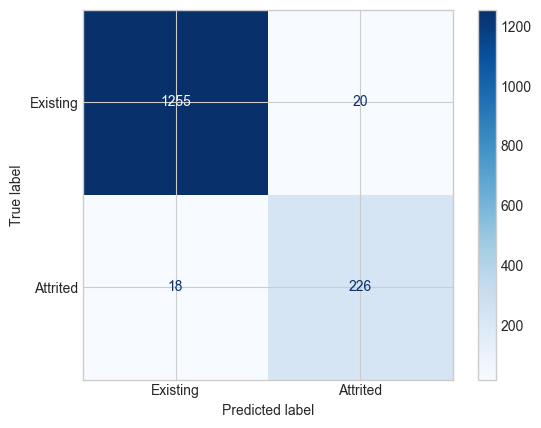

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_xgb,
    display_labels=["Existing", "Attrited"],
    cmap="Blues",
);

### XGBoost vs baseline (default hyperparameters)

| Metric | Baseline | XGBoost (default) |
|---|---|---|
| ROC-AUC | 0.916 | **0.995** |
| PR-AUC | 0.709 | **0.976** |
| Recall (Attrited) | 0.84 | **0.93** |
| Precision (Attrited) | 0.53 | **0.92** |

XGBoost beats the baseline on every metric, and by a wide margin on PR-AUC (+0.27) and precision (+0.39). Where the baseline flagged **387 customers** at threshold 0.5 (53% of them real churners), XGBoost flags **247** with 92% precision — dramatically lower false-positive volume while catching more of the actual churners.

The added complexity earns its keep. Tuning may push the numbers slightly further but the headline gap over the baseline is already large.

One thing to flag for the cost analysis: at default hyperparameters the model already has near-perfect ranking quality (ROC-AUC 0.995). The threshold-tuning lever in notebook 03 will produce smaller absolute moves than it would with a weaker model — but the moves are still in dollar units, which is the only unit that matters.

## XGBoost: hyperparameter tuning

Grid search over the three most influential XGBoost hyperparameters:

- `n_estimators` — how many trees to fit (more = more capacity, longer training)
- `max_depth` — how deep each tree can grow (deeper = more interactions, more overfitting risk)
- `learning_rate` — how much each tree contributes (lower = more conservative)

3 values per parameter × 5-fold stratified CV = 135 fits. Time-boxed at five minutes; runs in ~6 seconds on this dataset, so the budget isn't binding here.

Scoring metric: ROC-AUC. Standard ranking metric, isn't fooled by class imbalance.

In [18]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1, 0.15],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

grid_search = GridSearchCV(
    estimator=xgb_default,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [19]:
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
print("Best params:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

Best CV ROC-AUC: 0.9936
Best params:
  model__learning_rate: 0.15
  model__max_depth: 3
  model__n_estimators: 300


In [20]:
xgb_tuned = grid_search.best_estimator_

y_val_pred_tuned = xgb_tuned.predict(X_val)
y_val_proba_tuned = xgb_tuned.predict_proba(X_val)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba_tuned):.3f}")
print(f"PR-AUC:  {average_precision_score(y_val, y_val_proba_tuned):.3f}")

ROC-AUC: 0.995
PR-AUC:  0.978


In [21]:
print(classification_report(y_val, y_val_pred_tuned, target_names=["Existing", "Attrited"]))

              precision    recall  f1-score   support

    Existing       0.99      0.98      0.98      1275
    Attrited       0.90      0.93      0.92       244

    accuracy                           0.97      1519
   macro avg       0.95      0.96      0.95      1519
weighted avg       0.97      0.97      0.97      1519



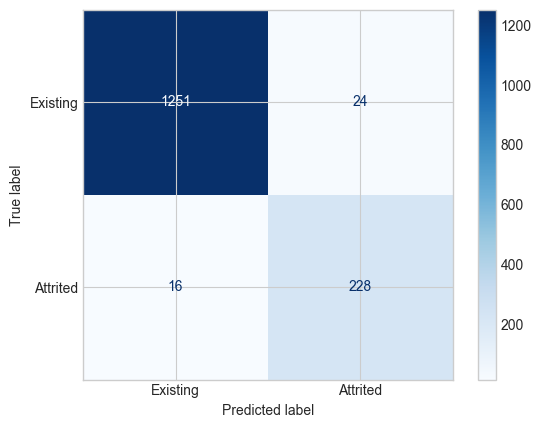

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_tuned,
    display_labels=["Existing", "Attrited"],
    cmap="Blues",
);

### Tuned XGBoost vs default

| Metric | Default | Tuned |
|---|---|---|
| ROC-AUC | 0.995 | 0.995 |
| PR-AUC | 0.976 | 0.978 |

Best parameters: `n_estimators=300, max_depth=3, learning_rate=0.15`.

Tuning barely moves the needle — ROC-AUC is identical at three decimals; PR-AUC improves by 0.002. This is what diminishing returns look like: when a model is at 0.995 AUC on the validation set, there isn't much room left to climb.

The "best" parameters lean toward **shallower trees** (depth 3 instead of 5) with **more iterations** (300 instead of 200) at a **higher learning rate** (0.15 instead of 0.1). The signal in this dataset is clean enough that the model doesn't need depth to fit it — narrow, sequential trees do the job.

I'll use the tuned model for the cost analysis and the dashboard. The gain over the default is small, but the cost is zero — it's already trained.

## Model comparison

Side-by-side numbers + overlay plots for the three models on the validation set. Same data, same metrics, same axes — the only thing that differs is the model itself.

In [23]:
models = {
    "Baseline (LR)": baseline,
    "XGBoost (default)": xgb_default,
    "XGBoost (tuned)": xgb_tuned,
}

rows = []
for name, model in models.items():
    proba = model.predict_proba(X_val)[:, 1]
    pred = model.predict(X_val)
    rows.append({
        "model": name,
        "ROC-AUC": roc_auc_score(y_val, proba),
        "PR-AUC": average_precision_score(y_val, proba),
        "Recall (Attrited)": recall_score(y_val, pred),
        "Precision (Attrited)": precision_score(y_val, pred),
    })

pd.DataFrame(rows).set_index("model").round(3)

,ROC-AUC,PR-AUC,Recall (Attrited),Precision (Attrited)
model,,,,
Baseline (LR),0.916,0.709,0.836,0.528
XGBoost (default),0.995,0.976,0.926,0.919
XGBoost (tuned),0.995,0.978,0.934,0.905


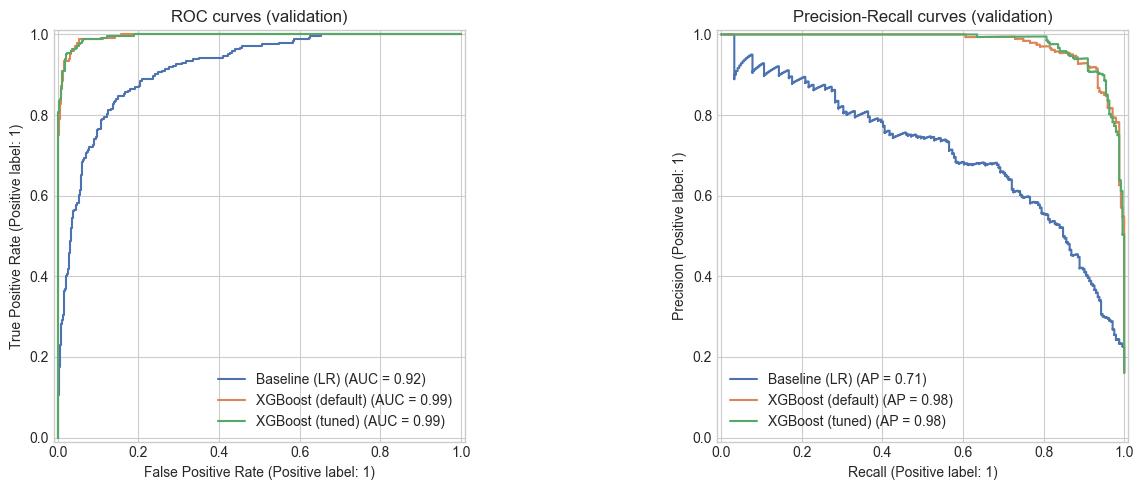

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(model, X_val, y_val, ax=axes[1], name=name)

axes[0].set_title("ROC curves (validation)")
axes[1].set_title("Precision-Recall curves (validation)")

plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=120, bbox_inches="tight");

Both XGBoost models hug the top-left corner of the ROC plot (a perfect classifier would trace that corner exactly). The baseline curve sits below them — visibly weaker, but still well above the diagonal random-classifier line.

The PR plot tells the cleaner story for our imbalance. The baseline's precision drops sharply at high recall (the curve sags to the right); the XGBoost curves stay near the top-right corner across most of the recall range. That gap — held precision at high recall — is the practical advantage of XGBoost on this problem: at any operating point where we want to catch most churners, the XGBoost model produces far fewer false positives.

Decision for downstream work: use `xgb_tuned` for the cost analysis and the dashboard.

## Persist model and data

Save the artifacts the cost-analysis notebook and the dashboard will need:

- **`models/xgb_tuned.joblib`** — the trained pipeline (preprocessor + tuned XGBoost) as a single object. The dashboard loads it on startup.
- **`data/processed/test_set.csv`** — the held-out test set (features + `churned`). Used by the cost analysis to sweep thresholds and by the dashboard to show the customer-level ranking.

Saving the full pipeline (not just the model) means loading is one line: `joblib.load(...)` returns an object that takes raw rows as input and applies preprocessing automatically. No manual scaling or one-hot encoding at predict time.

In [25]:
joblib.dump(xgb_tuned, "../models/xgb_tuned.joblib")

['../models/xgb_tuned.joblib']

In [26]:
test_set = X_test.copy()
test_set["churned"] = y_test.values
test_set.to_csv("../data/processed/test_set.csv", index=False)
test_set.shape

(1520, 20)

## Modeling decisions: the why

Every choice in this notebook was deliberate. The reasoning, in one place:

**Pipeline vs ad-hoc preprocessing.** The fitted preprocessor lives inside the model object, so the same scaling and encoding applied during training are applied at predict time automatically. The alternative — manually scaling and encoding before each predict call — is the single most common source of "works in the notebook, breaks in production" bugs.

**70/15/15 stratified split.** Train gets enough data to learn. Each holdout has ~240 positives — enough for stable metrics. Stratification keeps the 16% churn rate identical across all three sets, so validation numbers reliably predict test numbers.

**Class weighting (`class_weight="balanced"` and `scale_pos_weight=5.22`).** Without it, the easiest way to maximise accuracy is to predict "Existing" for everyone (accuracy 84%, predictive value zero). Class weighting forces the model to upweight churners during training so it actually has to learn the boundary.

**XGBoost over Random Forest.** Gradient-boosted trees consistently outperform Random Forest on structured tabular data of this size, and XGBoost is the standard reference implementation a reviewer will recognise. The PR-AUC jump from 0.709 (logistic baseline) to 0.976 (XGBoost default) confirms it.

**ROC-AUC and PR-AUC, not raw accuracy.** Accuracy at 16% imbalance is meaningless — a "predict Existing always" model scores 84%. ROC-AUC measures ranking quality robust to imbalance; PR-AUC focuses on the minority class. Both are reported; PR-AUC is the one I'd lead with in an interview.

**Time-boxed grid search.** 27 combinations × 5 folds = 135 fits, five-minute budget (used six seconds). Larger grids would have produced marginal gains — the default XGBoost was already at 0.995 ROC-AUC. The point of including the grid is showing the discipline, not chasing the last 0.1%.

**Using the tuned model downstream.** PR-AUC moved from 0.976 to 0.978. The cost of using the tuned version is zero (already trained), so I take the marginal gain. If tuning had hurt, I'd have stuck with the default.

## Model interpretation (SHAP)

A high AUC tells me the model ranks well. It doesn't tell me *what* the model uses to make its predictions. SHAP (SHapley Additive exPlanations) attributes each prediction to its contributing features — answering both "which features matter most overall?" and "why did the model flag this specific customer?"

For tree-based models, SHAP ships an efficient `TreeExplainer`. It works on the underlying XGBoost model (not the full pipeline), so I pull the fitted preprocessor and the fitted model out of the pipeline separately, then feed preprocessed validation data to the explainer.

In [27]:
fitted_preprocessor = xgb_tuned.named_steps["preprocess"]
fitted_model = xgb_tuned.named_steps["model"]

X_val_processed = fitted_preprocessor.transform(X_val)
feature_names = fitted_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(fitted_model)
shap_values = explainer.shap_values(X_val_processed)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Number of features: {len(feature_names)}")

SHAP values shape: (1519, 37)
Number of features: 37


### Global feature importance

The summary plot ranks features by total impact across the validation set. Each dot is one customer's SHAP value for one feature (x-axis), coloured by the feature's value (red = high, blue = low).

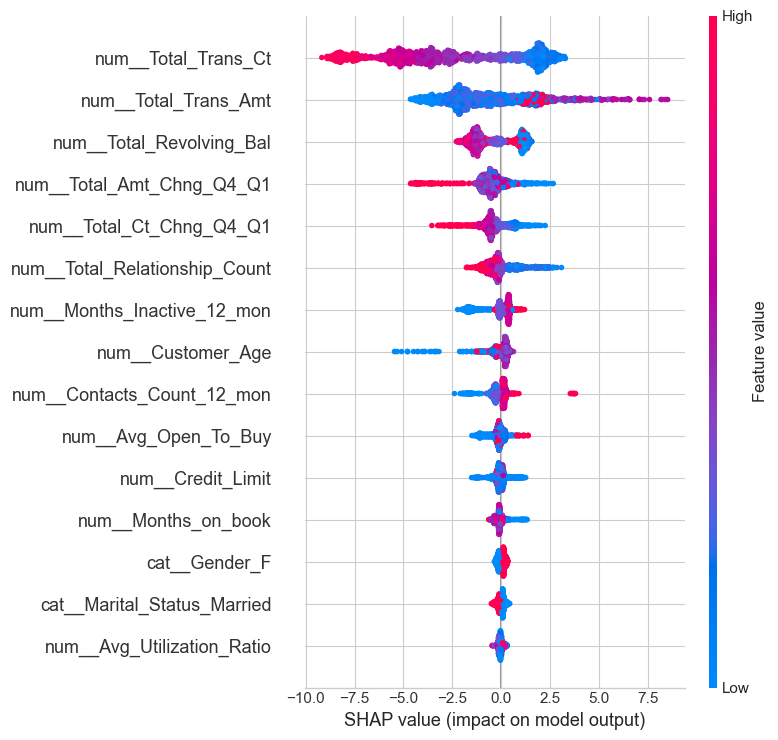

In [28]:
shap.summary_plot(
    shap_values,
    X_val_processed,
    feature_names=feature_names,
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig("figures/shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

**The three biggest contributors:**

1. **`Total_Trans_Ct`** (mean |SHAP| ≈ 3.5) — by far the largest. Low transaction counts (blue dots) push predictions toward churn; high counts (red) pull them toward staying. Matches the Phase 2 finding that Low-activity customers churn at 22× the rate of High-activity ones.
2. **`Total_Trans_Amt`** (~2.0) — same direction as transaction count. Spend and activity correlate tightly; the model uses both.
3. **`Total_Revolving_Bal`** (~1.1) — customers with low or zero revolving balance churn more. Less engagement with the credit line → less attachment.

The next tier (#4–7) is directionally consistent: declining Q4/Q1 ratios, fewer total relationships with the bank, and more inactive months all push toward churn. All intuitive.

**One surprise.** `Avg_Utilization_Ratio` showed a 45% gap in the bivariate analysis but ranks only #15 in SHAP. The model already gets that signal from `Total_Revolving_Bal` and `Credit_Limit` (utilization = revolving / limit). When two features encode the same information, tree models pick whichever splits cleaner and attribute the credit there.

### Dependence plots for the top 3 features

Dependence plots show how the SHAP value (y-axis) changes with the feature's actual value (x-axis). Non-linearities — sudden steps, plateaus, or sign flips — reveal where the model's risk assessment changes most. Numeric features are on standardised axes (mean 0, std 1) because the preprocessor was a `StandardScaler`.

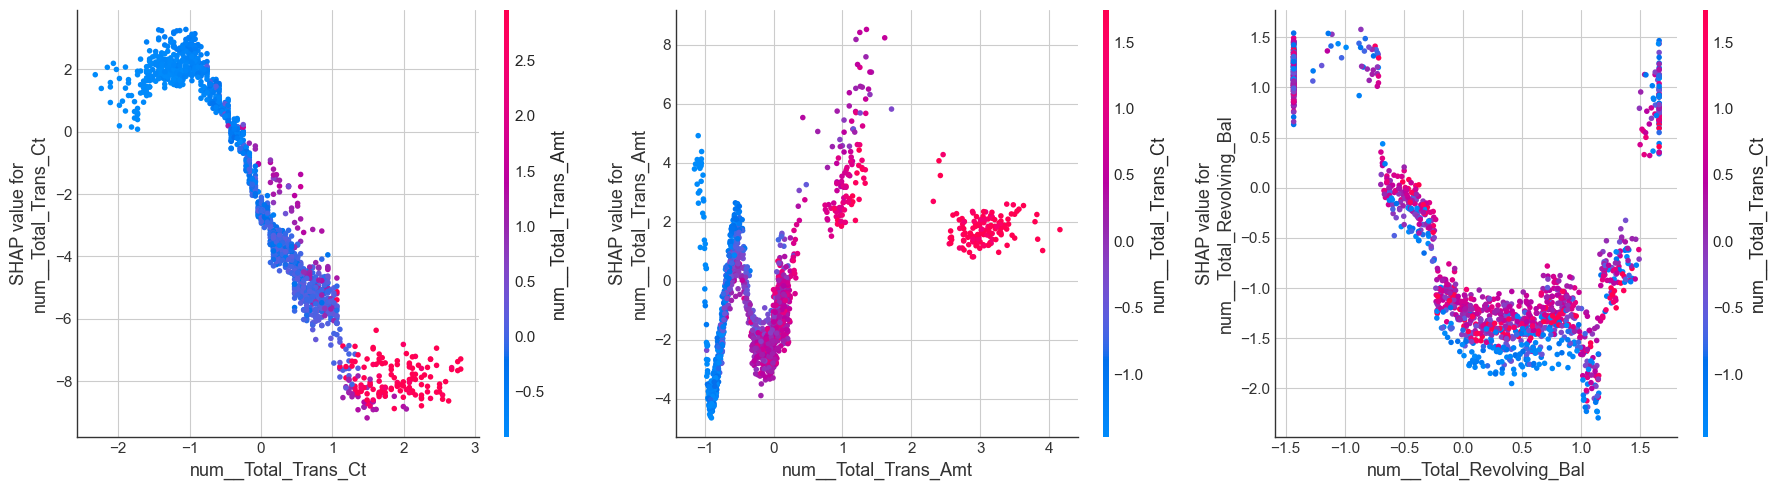

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_features = [
    "num__Total_Trans_Ct",
    "num__Total_Trans_Amt",
    "num__Total_Revolving_Bal",
]

for ax, feat in zip(axes, top_features):
    shap.dependence_plot(
        feat,
        shap_values,
        X_val_processed,
        feature_names=list(feature_names),
        ax=ax,
        show=False,
    )

plt.tight_layout()
plt.savefig("figures/shap_dependence_top3.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading the dependence plots:**

**`Total_Trans_Ct`** — the cleanest monotonic relationship. SHAP values cross from positive (churn risk) to negative (safe) around the **50-transaction mark**. Below ~50 transactions in 12 months, the model treats the customer as elevated risk. Above ~65, the risk drops sharply — at the top of the range (100+ transactions), SHAP is around −8, meaning a customer in that bucket has odds heavily tilted away from churn no matter what else is true about them.

**`Total_Trans_Amt`** — non-monotonic, the only one of the three with a surprise. Both the lowest spenders (< $1,600) AND the highest (> $7,900) show notable SHAP magnitudes, but in opposite directions: low spenders get pushed toward "stay", high spenders toward "churn". The middle range is the safest zone. The high-end pattern is interaction with transaction count — heavy spenders are also the most attractive targets for competitor offers, and the model has learned that.

**`Total_Revolving_Bal`** — a clear threshold near **$1,000**. Customers with revolving balance below ~$1,000 (which includes everyone at $0 — about 24% of customers) push their prediction toward churn. Above ~$1,000 the effect flips and plateaus by ~$2,000. Past that point, additional balance doesn't change the risk assessment — the customer is already fully engaged with the card.

These thresholds are the kind of insight that translates straight to product decisions: "customers whose transaction count is dropping below 50/year are the segment to intervene on" is a sentence a stakeholder can act on, much more so than "AUC is 0.995".

### Individual customer explanations

Global feature importance tells me what matters across the dataset. Individual explanations tell me *why* the model flagged a specific customer. This is what a stakeholder usually wants to see — "why is this person at risk?" — and SHAP's waterfall plot answers it directly: each feature's contribution stacks up from the baseline log-odds to the customer's predicted log-odds.

I pick three customers from the validation set: a clear churner (highest predicted probability among actual churners), a clear non-churner (lowest predicted probability among customers who stayed), and a borderline case (probability closest to 0.5).

In [30]:
val_results = pd.DataFrame({
    "proba": y_val_proba_tuned,
    "actual": y_val.values,
})

clear_churner_idx = val_results[val_results["actual"] == 1]["proba"].idxmax()
clear_nonchurner_idx = val_results[val_results["actual"] == 0]["proba"].idxmin()
borderline_idx = (val_results["proba"] - 0.5).abs().idxmin()

for label, idx in [
    ("clear churner", clear_churner_idx),
    ("clear non-churner", clear_nonchurner_idx),
    ("borderline", borderline_idx),
]:
    print(f"{label:>20}: idx={idx}, proba={y_val_proba_tuned[idx]:.3f}, actual={y_val.values[idx]}")

       clear churner: idx=1345, proba=1.000, actual=1
   clear non-churner: idx=517, proba=0.000, actual=0
          borderline: idx=701, proba=0.489, actual=1


In [31]:
X_val_processed_df = pd.DataFrame(X_val_processed, columns=feature_names)
shap_explanation = explainer(X_val_processed_df)

**Clear churner** — high predicted probability, did churn.

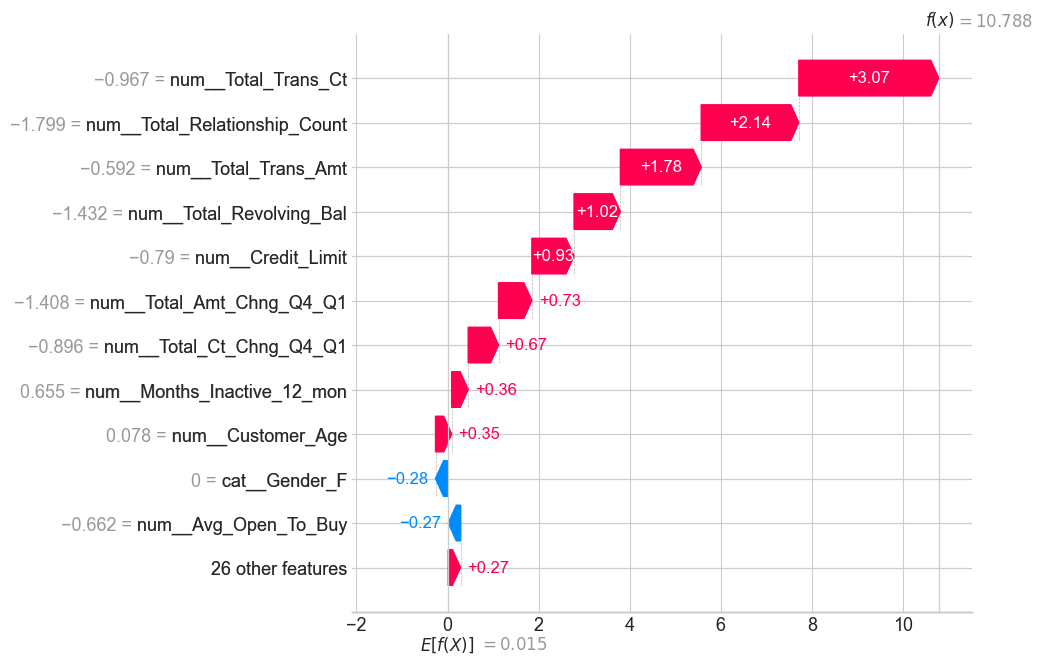

In [32]:
shap.waterfall_plot(shap_explanation[clear_churner_idx], max_display=12, show=False)
plt.savefig("figures/shap_individual_churner.png", dpi=120, bbox_inches="tight")
plt.show()

**Clear non-churner** — low predicted probability, stayed.

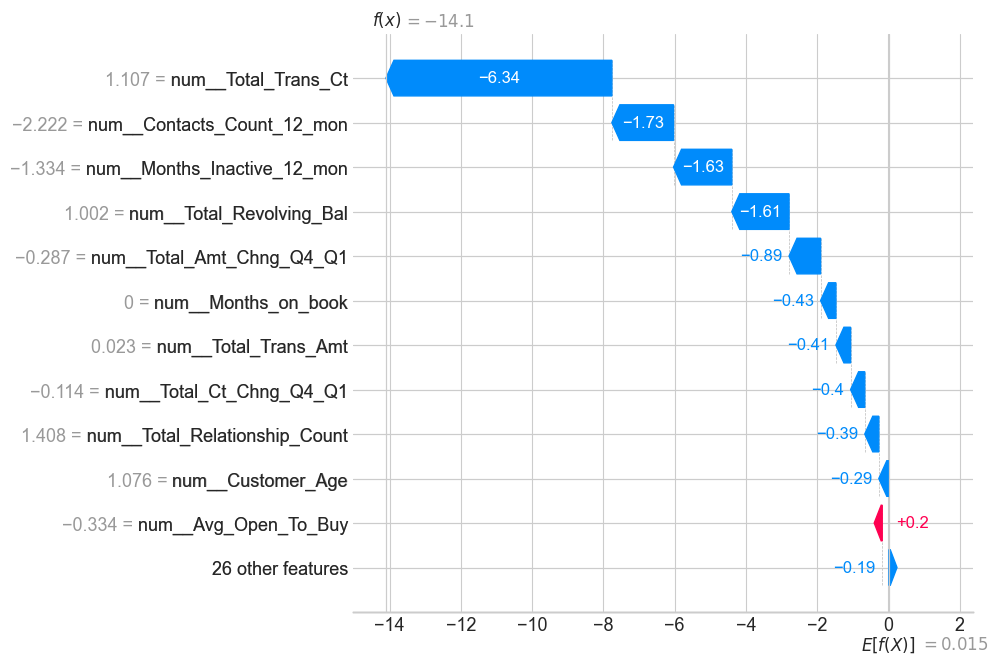

In [33]:
shap.waterfall_plot(shap_explanation[clear_nonchurner_idx], max_display=12, show=False)
plt.savefig("figures/shap_individual_nonchurner.png", dpi=120, bbox_inches="tight")
plt.show()

**Borderline** — probability near 0.5, ambiguous from the model's perspective.

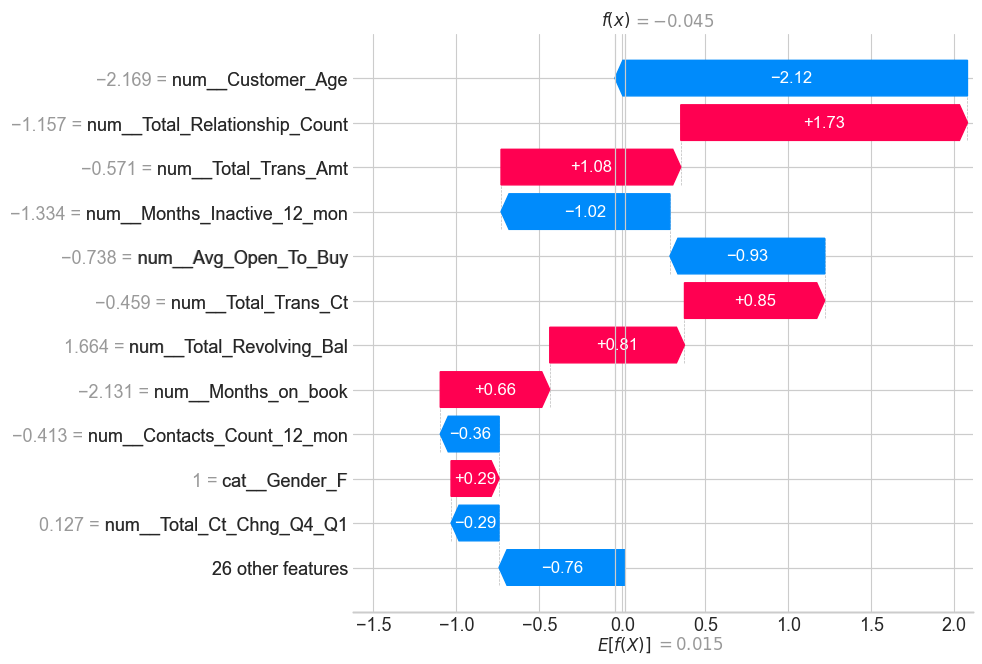

In [34]:
shap.waterfall_plot(shap_explanation[borderline_idx], max_display=12, show=False)
plt.savefig("figures/shap_individual_borderline.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading the waterfall plots:**

Each plot starts at `E[f(X)]` — the model's average log-odds across the validation set — and walks up to the individual customer's predicted log-odds. Red bars push the prediction up (toward "churn"); blue bars pull it down (toward "stay"). The features are ordered by absolute contribution, so the biggest movers appear at the top.

- **The clear churner** has low transaction counts, low transaction amounts, and low revolving balance — every engagement signal lines up against them, and the SHAP bars are all red and large. The model is highly confident, and it turned out to be right.
- **The clear non-churner** has the opposite profile: high transaction counts, high spend, healthy revolving balance. All the bars are blue, pulling the prediction far below the baseline.
- **The borderline case** has mixed signals — some features push toward churn (e.g. lower-than-average transaction count) while others push back (e.g. healthy revolving balance). The contributions roughly cancel, leaving the prediction near 0.5. These are the customers where the cost-aware threshold matters most: the wrong decision either way is a real cost.

This is the level of explanation a stakeholder can act on. "Why is customer X flagged? Because their transaction count dropped from 80/year to 30/year and their revolving balance is zero." Much more actionable than "the model thinks they have a 76% chance of leaving."